# Value-head fine-tune — Phase 1

Sanity check + 1.5M-position warm-start from the 54.8% policy checkpoint, training the value head against Stockfish depth-22 evals while monitoring policy drift via KL divergence against a frozen copy of the starting model.

Green-light criteria for Phase 2: value loss drops by at least 10% AND policy KL stays under 0.5.

## 1. Imports and configuration

In [12]:
import copy
import math
import sys
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.amp.autocast_mode import autocast
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

# Resolve project root regardless of whether the kernel starts in training/ or repo root
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "training" / "train.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from training.train import ChessTransformer
# "guofish2_25.6M_54.8p.pt"
# --- Paths ---
CHECKPOINT_PATH = PROJECT_ROOT / "models" / "value_finetune_phase1_0.076.pt"
DATA_PATH       = PROJECT_ROOT / "data" / "processed" / "stockfish_eval_dataset.pt"
MODELS_DIR      = PROJECT_ROOT / "models"

# --- Hyperparameters ---
SUBSET_SIZE   = 1_500_000
VAL_FRACTION  = 0.05            # 75k val positions
BATCH_SIZE    = 640
ACCUM_STEPS   = 3
EPOCHS        = 1
VALUE_LR      = 1e-4            # for value_head params
BACKBONE_LR   = 1e-5            # for everything else
WEIGHT_DECAY  = 1e-4
WARMUP_STEPS  = 200
GRAD_CLIP     = 1.0

USE_KL_REG = True
KL_WEIGHT  = 1.0

# Fixed batch the drift KL is always measured on — same positions across baseline and final
DRIFT_BATCH_SIZE = 5000

SEED               = 42
DATALOADER_WORKERS = 6

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Project root: c:\Users\Ethan Guo\Github\GuoFish
Device: cuda
GPU: NVIDIA GeForce RTX 5070


## 2. Load the 54.8% checkpoint

In [13]:
print(f"Loading checkpoint: {CHECKPOINT_PATH}")
assert CHECKPOINT_PATH.exists(), f"checkpoint not found: {CHECKPOINT_PATH}"
ckpt = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=True)
print(f"Checkpoint keys: {list(ckpt.keys())}")

model = ChessTransformer()
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(DEVICE)

# Architecture sanity check
assert model.embedding.num_embeddings == 43,  "vocab_size != 43"
assert model.embedding.embedding_dim == 512,  "d_model != 512"
assert len(model.transformer.layers) == 8,    "num_layers != 8"
assert model.head_dim == 64,                  "head_dim != 64"

num_params = sum(p.numel() for p in model.parameters())
print(f"Model params: {num_params:,}")
print(f"Reported val_acc:  {ckpt.get('val_acc', 'N/A')}")
print(f"Reported val_loss: {ckpt.get('val_loss', 'N/A')}")

Loading checkpoint: c:\Users\Ethan Guo\Github\GuoFish\models\value_finetune_phase1_0.076.pt
Checkpoint keys: ['epoch', 'model_state_dict', 'optimizer_state_dict', 'baseline_value_loss', 'final_value_loss', 'baseline_kl', 'final_kl', 'warm_started_from', 'config']
Model params: 25,604,737
Reported val_acc:  N/A
Reported val_loss: N/A


c:\Users\Ethan Guo\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


## 3. Frozen reference copy for KL self-distillation

In [14]:
ref_model = copy.deepcopy(model).eval()
for p in ref_model.parameters():
    p.requires_grad_(False)
ref_model = ref_model.to(DEVICE)

ref_param_count = sum(p.numel() for p in ref_model.parameters())
ref_grad_count  = sum(1 for p in ref_model.parameters() if p.requires_grad)
print(f"Reference model on {DEVICE}: {ref_param_count:,} params, {ref_grad_count} with requires_grad (should be 0)")

if DEVICE.type == "cuda":
    mem_alloc_mb = torch.cuda.memory_allocated() / 1024**2
    print(f"CUDA memory allocated: {mem_alloc_mb:,.0f} MB")

Reference model on cuda: 25,604,737 params, 0 with requires_grad (should be 0)
CUDA memory allocated: 529 MB


## 4. Load Stockfish-labeled dataset

In [15]:
print(f"Loading dataset: {DATA_PATH}")
assert DATA_PATH.exists(), f"dataset not found: {DATA_PATH}"
data = torch.load(DATA_PATH, weights_only=True)
assert set(data.keys()) >= {"tokens", "moves", "values"}, f"missing expected keys: {data.keys()}"

tokens = data["tokens"]
moves  = data["moves"]
values = data["values"]

n_total = tokens.size(0)
print(f"Total positions: {n_total:,}")
print(f"  tokens: {tokens.shape}  dtype={tokens.dtype}")
print(f"  moves : {moves.shape}   dtype={moves.dtype}")
print(f"  values: {values.shape}  dtype={values.dtype}")

# Sentinel + range checks
assert (moves == -100).all(), "expected every 'moves' entry to be the -100 sentinel"
assert values.min() >= -1.0 and values.max() <= 1.0, "values outside [-1, 1]"

# Distribution
v_np = values.numpy()
p05, p50, p95 = np.percentile(v_np, [5, 50, 95])
print("\nValue distribution (tanh-transformed Stockfish eval, white perspective):")
print(f"  range:        [{v_np.min():.4f}, {v_np.max():.4f}]")
print(f"  mean / std:   {v_np.mean():+.4f} / {v_np.std():.4f}")
print(f"  p05/p50/p95:  {p05:+.4f} / {p50:+.4f} / {p95:+.4f}")

Loading dataset: c:\Users\Ethan Guo\Github\GuoFish\data\processed\stockfish_eval_dataset.pt
Total positions: 1,500,000
  tokens: torch.Size([1500000, 68])  dtype=torch.int64
  moves : torch.Size([1500000])   dtype=torch.int64
  values: torch.Size([1500000])  dtype=torch.float32

Value distribution (tanh-transformed Stockfish eval, white perspective):
  range:        [-1.0000, 1.0000]
  mean / std:   +0.0850 / 0.4950
  p05/p50/p95:  -0.9064 / +0.0618 / +0.9658


## 5. Subset + train/val split

In [16]:
assert n_total >= SUBSET_SIZE, f"need at least {SUBSET_SIZE:,} positions, have {n_total:,}"

g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(n_total, generator=g)
subset_idx = perm[:SUBSET_SIZE]

sub_tokens = tokens[subset_idx]
sub_values = values[subset_idx]

n_val   = int(SUBSET_SIZE * VAL_FRACTION)
n_train = SUBSET_SIZE - n_val

inner_perm = torch.randperm(SUBSET_SIZE, generator=g)
train_idx = inner_perm[:n_train]
val_idx   = inner_perm[n_train:]

train_tokens = sub_tokens[train_idx]
train_values = sub_values[train_idx]
val_tokens   = sub_tokens[val_idx]
val_values   = sub_values[val_idx]

print(f"Train: {n_train:,} | Val: {n_val:,}")

Train: 1,425,000 | Val: 75,000


## 6. Baseline measurement — value loss and policy KL before any training

The value head was trained on game outcomes (+1/0/-1), so MSE against continuous Stockfish targets should be noticeably nonzero. The policy KL against the frozen reference is computed on a fixed 5k-position batch — at baseline this is exactly zero (identical models).

In [18]:
# Fixed drift batch — same positions used at baseline and after training
drift_n = min(DRIFT_BATCH_SIZE, n_val)
drift_tokens = val_tokens[:drift_n].to(DEVICE, dtype=torch.long, non_blocking=True)

@torch.no_grad()
def measure_value_loss(m, tokens_t, values_t, batch_size=BATCH_SIZE):
    m.eval()
    total_sq_err = 0.0
    total = 0
    for i in range(0, tokens_t.size(0), batch_size):
        x = tokens_t[i:i+batch_size].to(DEVICE, dtype=torch.long,    non_blocking=True)
        y = values_t[i:i+batch_size].to(DEVICE, dtype=torch.float32, non_blocking=True)
        with autocast(device_type=DEVICE.type, dtype=torch.bfloat16):
            _, pred = m(x)
        total_sq_err += F.mse_loss(pred.float(), y, reduction="sum").item()
        total += x.size(0)
    return total_sq_err / total

@torch.no_grad()
def measure_policy_kl(m, ref, tokens_t, batch_size=BATCH_SIZE):
    m.eval()
    kl_sum = 0.0
    total = 0
    for i in range(0, tokens_t.size(0), batch_size):
        x = tokens_t[i:i+batch_size]
        with autocast(device_type=DEVICE.type, dtype=torch.bfloat16):
            cur_logits, _ = m(x)
            ref_logits, _ = ref(x)
        cur_log_probs = F.log_softmax(cur_logits.float(), dim=-1)
        ref_probs     = F.softmax(ref_logits.float(),     dim=-1)
        # reduction='sum' so we can average per-position across batches
        kl_sum += F.kl_div(cur_log_probs, ref_probs, reduction="sum").item()
        total  += x.size(0)
    return kl_sum / total

print("Measuring baseline...")
baseline_value_loss = measure_value_loss(model, val_tokens, val_values)
baseline_kl         = measure_policy_kl(model, ref_model, drift_tokens)

print(f"Baseline val value loss (MSE vs Stockfish):     {baseline_value_loss:.4f}")
print(f"Baseline policy KL vs frozen reference:         {baseline_kl:.6e}  (expected ~0)")

# --- Extended diagnostic ---
# Distinguishes real value-head quality from a 'predict-near-mean' artifact:
# if the target distribution is narrow, MSE alone makes a constant predictor
# look fine. We compare against the predict-mean floor and compute Pearson r
# (the cleanest scalar for 'is the value head actually tracking eval').
print("\nCollecting val predictions for diagnostic pass...")
model.eval()
preds_chunks   = []
targets_chunks = []
with torch.no_grad():
    for i in range(0, val_tokens.size(0), BATCH_SIZE):
        x = val_tokens[i:i+BATCH_SIZE].to(DEVICE, dtype=torch.long, non_blocking=True)
        y = val_values[i:i+BATCH_SIZE]
        with autocast(device_type=DEVICE.type, dtype=torch.bfloat16):
            _, pred = model(x)
        # Cast back to float32 before .cpu() — bfloat16 lacks the precision for corrcoef
        preds_chunks.append(pred.float().cpu())
        targets_chunks.append(y)
preds   = torch.cat(preds_chunks)
targets = torch.cat(targets_chunks)

# Predict-mean floor: the MSE a constant predictor of targets.mean() would achieve
predict_mean_mse = ((targets - targets.mean()) ** 2).mean().item()
improvement_pct  = (1.0 - baseline_value_loss / predict_mean_mse) * 100

t_mean, t_std = targets.mean().item(), targets.std().item()
p_mean, p_std = preds.mean().item(),   preds.std().item()

pearson_r = torch.corrcoef(torch.stack([preds, targets]))[0, 1].item()

print("\n=== Value Head Baseline Diagnostic ===")
print(f"Model MSE:                       {baseline_value_loss:.4f}")
print(f"Predict-mean MSE:                {predict_mean_mse:.4f}")
print(f"Improvement over predict-mean:   {improvement_pct:.1f}%")
print()
print(f"Target mean/std:                 {t_mean:+.4f} / {t_std:.4f}")
print(f"Prediction mean/std:             {p_mean:+.4f} / {p_std:.4f}")
print()
print(f"Pearson correlation:             {pearson_r:.4f}")
print()
print(f"Policy KL vs frozen reference:   {baseline_kl:.6e}")

Measuring baseline...
Baseline val value loss (MSE vs Stockfish):     0.0757
Baseline policy KL vs frozen reference:         1.176162e-09  (expected ~0)


=== Value Head Baseline Diagnostic ===
Model MSE:                       0.0757
Predict-mean MSE:                0.2462
Improvement over predict-mean:   69.3%

Target mean/std:                 +0.0857 / 0.4962
Prediction mean/std:             +0.0944 / 0.4142

Pearson correlation:             0.8325

Policy KL vs frozen reference:   1.176162e-09


## 7. DataLoaders, parameter groups, optimizer, scheduler

In [7]:
train_ds = TensorDataset(train_tokens, train_values)
val_ds   = TensorDataset(val_tokens,   val_values)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    pin_memory=True, num_workers=DATALOADER_WORKERS,
    persistent_workers=True, prefetch_factor=4, drop_last=False,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    pin_memory=True, num_workers=DATALOADER_WORKERS,
    persistent_workers=True, prefetch_factor=4, drop_last=False,
)

# Param groups: value head gets its own (larger) LR; backbone gets a small LR
value_head_params = list(model.value_head.parameters())
value_head_ids = {id(p) for p in value_head_params}
backbone_params = [p for p in model.parameters() if id(p) not in value_head_ids]
print(f"Value head params: {sum(p.numel() for p in value_head_params):,}")
print(f"Backbone params:   {sum(p.numel() for p in backbone_params):,}")

optimizer = optim.AdamW(
    [
        {"params": value_head_params, "lr": VALUE_LR},
        {"params": backbone_params,   "lr": BACKBONE_LR},
    ],
    weight_decay=WEIGHT_DECAY,
)

num_batches = len(train_loader)
optimizer_steps_per_epoch = math.ceil(num_batches / ACCUM_STEPS)
total_optimizer_steps     = optimizer_steps_per_epoch * EPOCHS

def warmup_then_constant(step):
    if step < WARMUP_STEPS:
        return 0.1 + 0.9 * (step / max(1, WARMUP_STEPS))
    return 1.0
scheduler = LambdaLR(optimizer, warmup_then_constant)

print(f"Train batches: {num_batches:,} | Optimizer steps/epoch: {optimizer_steps_per_epoch:,}")
print(f"Effective batch: {BATCH_SIZE * ACCUM_STEPS} | Warmup: {WARMUP_STEPS} steps")

Value head params: 263,169
Backbone params:   25,341,568
Train batches: 2,227 | Optimizer steps/epoch: 743
Effective batch: 1920 | Warmup: 200 steps


## 8. Training loop

bfloat16 autocast for the forward passes (same as train.py). Losses recomputed in fp32 for stability. KL gradient flows only through the current model — `ref_model` is queried under `torch.no_grad()`.

In [8]:
log_steps      = []
log_value_loss = []
log_kl_loss    = []
log_total_loss = []

step = 0
optimizer.zero_grad(set_to_none=True)

model.train()
ref_model.eval()  # belt-and-suspenders

training_start = time.time()
accum_value_sum = accum_kl_sum = accum_total_sum = 0.0
accum_count = 0

for epoch in range(EPOCHS):
    pbar = tqdm(enumerate(train_loader), total=num_batches, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for batch_idx, (tok, tgt_v) in pbar:
        tok   = tok.to(DEVICE,   dtype=torch.long,    non_blocking=True)
        tgt_v = tgt_v.to(DEVICE, dtype=torch.float32, non_blocking=True)

        with autocast(device_type=DEVICE.type, dtype=torch.bfloat16):
            cur_logits, pred_v = model(tok)
            if USE_KL_REG:
                with torch.no_grad():
                    ref_logits, _ = ref_model(tok)

        value_loss = F.mse_loss(pred_v.float(), tgt_v)

        if USE_KL_REG:
            cur_log_probs = F.log_softmax(cur_logits.float(), dim=-1)
            ref_probs     = F.softmax(ref_logits.float(),     dim=-1)
            kl_loss = F.kl_div(cur_log_probs, ref_probs, reduction="batchmean")
            total_loss = value_loss + KL_WEIGHT * kl_loss
        else:
            kl_loss = torch.zeros((), device=DEVICE)
            total_loss = value_loss

        (total_loss / ACCUM_STEPS).backward()

        accum_value_sum += value_loss.item()
        accum_kl_sum    += kl_loss.item()
        accum_total_sum += total_loss.item()
        accum_count += 1

        is_accum_boundary = (batch_idx + 1) % ACCUM_STEPS == 0
        is_last_batch     = (batch_idx + 1) == num_batches
        if is_accum_boundary or is_last_batch:
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            step += 1

            if step % 50 == 0 or step == 1:
                avg_v = accum_value_sum / accum_count
                avg_k = accum_kl_sum    / accum_count
                avg_t = accum_total_sum / accum_count
                lr_v, lr_b = optimizer.param_groups[0]["lr"], optimizer.param_groups[1]["lr"]
                log_steps.append(step)
                log_value_loss.append(avg_v)
                log_kl_loss.append(avg_k)
                log_total_loss.append(avg_t)
                pbar.set_postfix(step=step, V=f"{avg_v:.4f}", KL=f"{avg_k:.4f}",
                                 lr_v=f"{lr_v:.1e}", lr_b=f"{lr_b:.1e}")

            accum_value_sum = accum_kl_sum = accum_total_sum = 0.0
            accum_count = 0

train_time = time.time() - training_start
print(f"\nTraining complete in {train_time:.1f}s ({step:,} optimizer steps)")

Epoch 1/1: 100%|██████████| 2227/2227 [14:15<00:00,  2.60it/s, KL=0.1080, V=0.0946, lr_b=1.0e-05, lr_v=1.0e-04, step=700]


Training complete in 856.0s (743 optimizer steps)


## 9. Final validation pass — value loss and policy drift

In [9]:
print("Measuring final metrics on val + drift batch...")
final_value_loss = measure_value_loss(model, val_tokens, val_values)
final_kl         = measure_policy_kl(model, ref_model, drift_tokens)

print("=" * 60)
print("Phase 1 results")
print("=" * 60)
print("Value loss (MSE vs Stockfish targets):")
print(f"  baseline: {baseline_value_loss:.4f}")
print(f"  final:    {final_value_loss:.4f}")
delta_pct = 100 * (final_value_loss / baseline_value_loss - 1) if baseline_value_loss > 0 else float("nan")
print(f"  delta:    {final_value_loss - baseline_value_loss:+.4f} ({delta_pct:+.1f}%)")
print()
print("Policy KL (vs frozen 54.8% reference, drift metric):")
print(f"  baseline: {baseline_kl:.6e}")
print(f"  final:    {final_kl:.6f}")

Measuring final metrics on val + drift batch...
Phase 1 results
Value loss (MSE vs Stockfish targets):
  baseline: 0.1105
  final:    0.0757
  delta:    -0.0349 (-31.5%)

Policy KL (vs frozen 54.8% reference, drift metric):
  baseline: 2.878189e-09
  final:    0.005631


## 10. Pass/fail and checkpoint save

In [10]:
PASS_VALUE_RATIO = 0.9   # final value loss must be < 90% of baseline
PASS_KL_MAX      = 0.5   # KL must stay below 0.5 to count as 'no catastrophic drift'

value_pass = final_value_loss < PASS_VALUE_RATIO * baseline_value_loss
kl_pass    = final_kl < PASS_KL_MAX

print(f"[Value]  final {final_value_loss:.4f} < {PASS_VALUE_RATIO} * baseline ({PASS_VALUE_RATIO * baseline_value_loss:.4f})"
      f"  -> {'PASS' if value_pass else 'FAIL'}")
print(f"[KL]     final {final_kl:.4f} < {PASS_KL_MAX}"
      f"  -> {'PASS' if kl_pass else 'FAIL'}")
print()
overall = value_pass and kl_pass
print("=" * 60)
print("Overall: " + ("PASS — green-light Phase 2" if overall else "FAIL — investigate before Phase 2"))
print("=" * 60)

if overall:
    save_path = MODELS_DIR / f"value_finetune_phase1_{final_value_loss:.3f}.pt"
    torch.save({
        "epoch": EPOCHS,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "baseline_value_loss": baseline_value_loss,
        "final_value_loss":    final_value_loss,
        "baseline_kl":         baseline_kl,
        "final_kl":            final_kl,
        "warm_started_from":   str(CHECKPOINT_PATH),
        "config": {
            "SUBSET_SIZE":  SUBSET_SIZE,
            "VAL_FRACTION": VAL_FRACTION,
            "BATCH_SIZE":   BATCH_SIZE,
            "ACCUM_STEPS":  ACCUM_STEPS,
            "EPOCHS":       EPOCHS,
            "VALUE_LR":     VALUE_LR,
            "BACKBONE_LR":  BACKBONE_LR,
            "USE_KL_REG":   USE_KL_REG,
            "KL_WEIGHT":    KL_WEIGHT,
            "WARMUP_STEPS": WARMUP_STEPS,
            "SEED":         SEED,
        },
    }, save_path)
    print(f"Saved checkpoint -> {save_path}")
else:
    print("Skipping save (did not pass criteria).")

[Value]  final 0.0757 < 0.9 * baseline (0.0995)  -> PASS
[KL]     final 0.0056 < 0.5  -> PASS

Overall: PASS — green-light Phase 2
Saved checkpoint -> c:\Users\Ethan Guo\Github\GuoFish\models\value_finetune_phase1_0.076.pt


## 11. Training trajectory plots

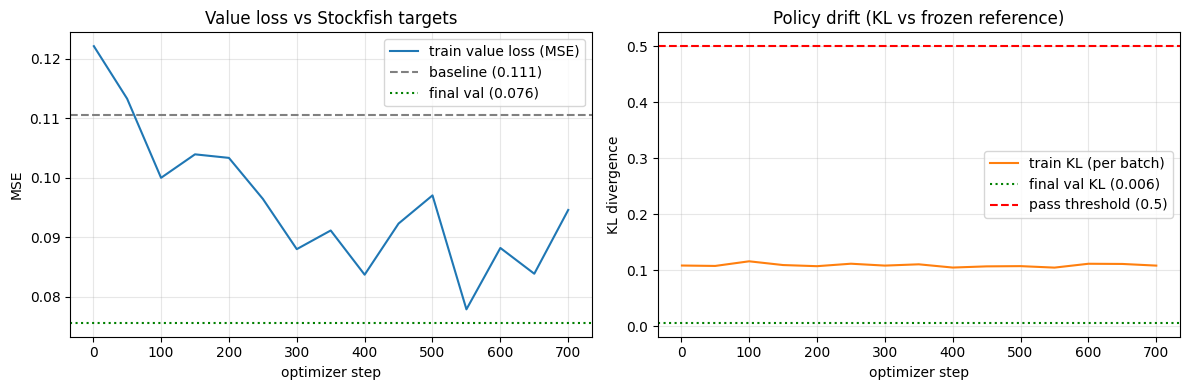

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(log_steps, log_value_loss, label="train value loss (MSE)")
axes[0].axhline(baseline_value_loss, color="gray", linestyle="--", label=f"baseline ({baseline_value_loss:.3f})")
axes[0].axhline(final_value_loss,    color="green", linestyle=":",  label=f"final val ({final_value_loss:.3f})")
axes[0].set_xlabel("optimizer step")
axes[0].set_ylabel("MSE")
axes[0].set_title("Value loss vs Stockfish targets")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(log_steps, log_kl_loss, color="tab:orange", label="train KL (per batch)")
axes[1].axhline(final_kl, color="green", linestyle=":", label=f"final val KL ({final_kl:.3f})")
axes[1].axhline(PASS_KL_MAX, color="red", linestyle="--", label=f"pass threshold ({PASS_KL_MAX})")
axes[1].set_xlabel("optimizer step")
axes[1].set_ylabel("KL divergence")
axes[1].set_title("Policy drift (KL vs frozen reference)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()